In [14]:
%pip install hmmlearn

In [15]:
import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Adjust this to your current repo if it changed
    repo_url = "https://github.com/egil10/stk-mat2011.git"
    repo_dir = "/content/stk-mat2011"

    if not os.path.exists(repo_dir):
        print(f"Cloning {repo_url}...")
        !git clone {repo_url} {repo_dir}
    else:
        print("Pulling latest changes...")
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

Pulling latest changes...
Already up to date.
Working directory: /content/stk-mat2011/code/notebooks


In [16]:
# Device Selection (Standard Archive Style)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Smart Path logic from archive)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data_path = Path("/content/stk-mat2011/code/data/processed/eurusd_clean_returns_jan2026.parquet")
    out_dir = Path("/content/drive/MyDrive/STK-MAT2011/models/sweeps")
else:
    data_path = Path("../data/processed/eurusd_clean_returns_jan2026.parquet")
    out_dir = Path("../models/sweeps")

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Data Path: {data_path}")
print(f"Output Directory: {out_dir}")

Mounted at /content/drive
Data Path: /content/stk-mat2011/code/data/processed/eurusd_clean_returns_jan2026.parquet
Output Directory: /content/drive/MyDrive/STK-MAT2011/models/sweeps


In [17]:
# Pull the data from your Google Drive into the local Colab disk
import sys
sys.path.append("/content/stk-mat2011/code/scripts")
from p_drive import sync_data

# This copies the file from MyDrive/GITHUB-COLAB/stk-mat2011/data/
# to the local path: ../data/processed/eurusd_clean_returns_jan2026.parquet
sync_data("../data/processed/eurusd_clean_returns_jan2026.parquet", to_drive=False)

Loaded eurusd_clean_returns_jan2026.parquet from Google Drive to Local ✅


In [18]:
from hmmlearn.hmm import GaussianHMM
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Load Data
df = pd.read_parquet(data_path)
y = df['returns'].values.reshape(-1, 1)

def fit_best_hmm(k, X, n_restarts=50):
    """
    Fits HMM multiple times and picks the best one.
    Higher n_restarts = better chance of finding the true global optimum.
    """
    best_ll = -np.inf
    best_model = None
    
    for seed in range(n_restarts):
        model = GaussianHMM(n_components=k, covariance_type="full", n_iter=1000, random_state=seed)
        try:
            model.fit(X)
            if model.score(X) > best_ll:
                best_ll = model.score(X)
                best_model = model
        except:
            continue
    
    # BIC Calculation: n_params * ln(N) - 2 * ln(L)
    n_params = k**2 + 2*k 
    bic = np.log(len(X)) * n_params - 2 * best_ll
    return k, bic, best_model

# RUN THE TURBO SWEEP (Parallelized)
print("Starting Parallel BIC Sweep for K=(2..8)...")
results = Parallel(n_jobs=-1)(delayed(fit_best_hmm)(k, y) for k in range(2, 9))

# Unpack for plotting
ks, bics, models = zip(*results)
print("Sweep Complete.")


Starting Parallel BIC Sweep for K=(2..8)...
Sweep Complete.


OPIMTAL NUMBER OF STATES: K = 2


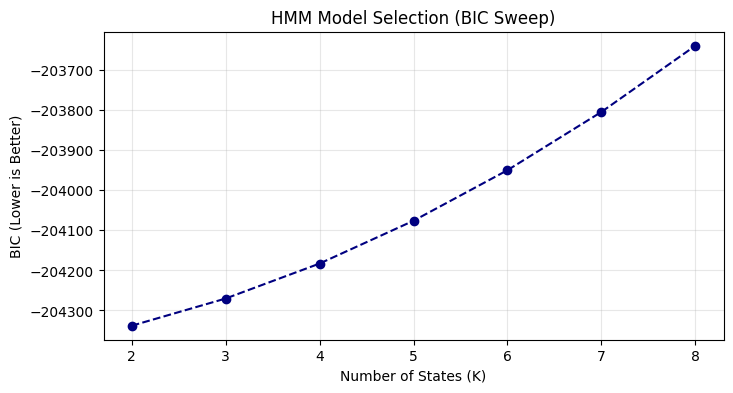

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(ks, bics, marker='o', ls='--', color='navy')
plt.title("HMM Model Selection (BIC Sweep)")
plt.xlabel("Number of States (K)")
plt.ylabel("BIC (Lower is Better)")
plt.grid(True, alpha=0.3)

best_k = ks[np.argmin(bics)]
print(f"OPIMTAL NUMBER OF STATES: K = {best_k}")
plt.show()

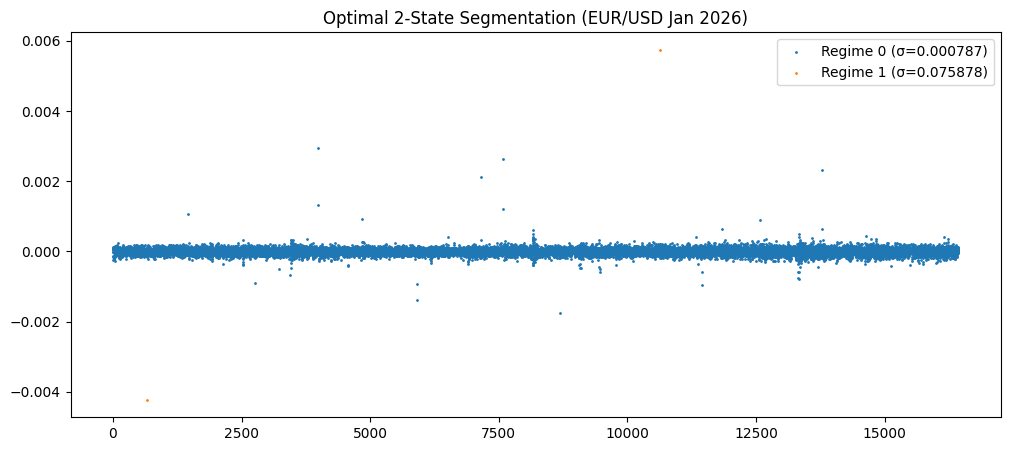

In [20]:
best_model = next(m for k, b, m in results if k == best_k)
states = best_model.predict(y)

plt.figure(figsize=(12, 5))
for i in range(best_k):
    mask = (states == i)
    plt.scatter(np.where(mask)[0], y[mask], s=1, label=f'Regime {i} (σ={np.sqrt(best_model.covars_[i][0][0]):.6f})')

plt.title(f"Optimal {best_k}-State Segmentation (EUR/USD Jan 2026)")
plt.legend()
plt.show()
